<p style="padding:5px;background-color:#007f99 ;border:1px solid black;border-radius:20px;font-weight:bold;font-size:2em;padding:15px;text-align:center;"> 
  TP graphes
    <br>

</p> 

Ce TP a pour but de vous faire travailler les implémentations de structure de données, et les parcours de graphe. 

Commencez par executer la cellule suivante : 

In [1]:
from lib import *

# I. Graphes non pondérés
!!! info Les dictionnaires en python
Dans le cours sur les graphes, on manipule souvent des dictionnaires. Ce sont une structure qui permet d'associer des "clés" (souvent des chaines de caractère) à des "valeurs".

On les créé avec des accolades : 
```python
d = {
    "clé": "valeur",
    "une autre clé": ["les", "valeurs", "peuvent", "être", "n'importe", "quel", "type"], 
    "jamais deux sans trois": 3
}
```

Les dictionnaires permettent d'accéder facilement à la valeur correspondant à une clé : 
```python
d["clé"] #renvoie "valeur"
```

Mais aussi de modifier la valeur associée à une clé, ou d'insérer un nouveau couple (clé, valeur) : 
```python
d["clé"] = "nouvelle valeur"
d["nouvelle clé"] = [1, 2, 3]
```
Dans cet exemple, lorsque la clé existe, la valeur est remplacée, et lorsqu'elle n'existe pas, elle est créée.

Enfin, on peut faire une boucle `for` sur les dictionnaires de la manière suivante : 
```python
for cle in d:
    #faire quelque chose avec les éléments
```

`cle` prend ici successivement la valeurs de toutes les clés du dictionnaire, dans un ordre arbitraire. 
!!!

## Préliminaires sur les graphes

On considère des graphes non-orientés. Les noeuds sont étiquetés par des chaines de caractères.

On choisi pour représenter les graphes une représentation en "liste d'adjacence".

!!! question Question 1
Quel type python correspondrait à une telle représentation ici ? 
!!!

??? info Une liste de liste chaines de caractères
Et non, car on étiquette les noeuds par des chaines de caractères. Ca aurait été la cas si on avait eu des noeuds entiers consécutifs. 
???

??? info Une liste de dictionnaires de couples (flottant, flottant)
Non plus ! 
???

??? info Un dictionnaire de liste de chaines de caractères
C'est ça ! Le dictionnaire associe à chaque noeud la liste de ses voisins, et le poids de chaque lien. 
???

??? info Un dictionnaire de dictionnaires de chaines de caractères
Ca fait beaucoup de dictionnaires là non ? 
???

!!! question Question 2
Déclarer une variable `graphe_1` contenant le graphe suivant, qui représente les liaisons ferrovières entre les villes. 

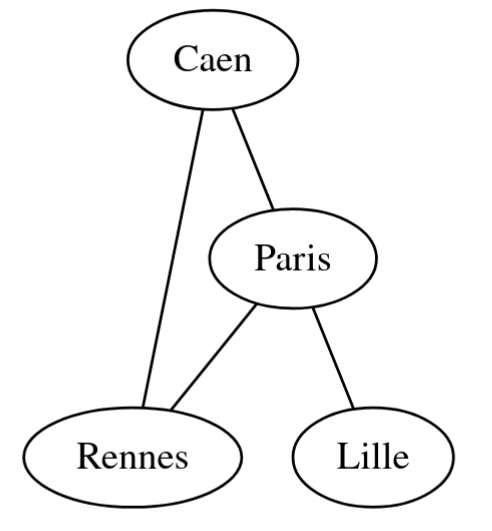

!!!

??? abstract Réponse (ne pas regarder avant d'être satisfait de votre réponse !)
```python 
graphe_1 = {"Caen": ["Paris", "Rennes"],
         "Paris": ["Caen", "Rennes","Lille"], 
         "Rennes": ["Caen", "Paris"], 
         "Lille": ["Paris"]}
```
???

!!! info Afficher un graphe
On vous fourni une fonction pour afficher un graphe : `afficher_graphe(graphe)`. Attention, pour fonctionner, elle doit être seule dans sa cellule ! 
!!!

!!! question Question 3
Affichez le graphe ci-dessus. Est-ce le même ? 
!!!

!!! question Question 4
Ce graphe est-il connexe ? 
!!!

!!! question Question 5 
On vous donne cette fois un nouveau graphe, représentant le réseau ferrovière nord-américain. Affichez-le. Est-il connexe ? 
!!!

In [6]:
graphe_2 = {"New York": ["Washington", "Montreal"], 
           "Anchorage": ["Fairbanks"], 
           "Washington": ["New York", "Chicago"], 
           "Chicago": ["Los Angeles", "Washington", "Montreal", "Seattle"], 
           "Los Angeles": ["Chicago", "Seattle"], 
           "Fairbanks": ["Anchorage"], 
           "Seattle": ["Los Angeles", "Chicago", "Vancouver"], 
           "Vancouver": ["Seattle", "Montreal"], 
           "Montreal": ["Vancouver", "New York", "Chicago"]}

## Détecter si un graphe est connexe

On aimerais désormais écrire une fonction pour déterminer si un graphe est connexe, ou non.

Pour cela, on va partir d'un sommet, puis suivre les arrêtes tant que c'est possible. Si on arrive à atteindre tous les sommets depuis notre sommet initial, c'est que le graphe est connexe.

!!! question Q6 
Compléter la fonction suivante, en remplacant les `...` par du code faisant ce que le commentaire indique. Que fait cette fonction ? 
!!!

??? info Réponse 
Cette fonction parcours le graphe en suivant les arrêtes, en notant tous les sommets qu'elle parcours. 
???

In [ ]:

def parcours(g, s, deja_vu):
    """g est un graphe, s est un sommet, deja_vu est un dictionnaire de sommets vers des booléens"""
    
    # si le sommet s est à vrai dans deja_vu, renvoyer sans rien faire
    
    ...
    
    # sinon, ajouter le sommet s à deja_vu avec la valeur `True`
    
    ...
    
    # parcourir tous les voisins de s
    
    ...
    
        # pour chaque voisin v, appelez parcours(g, v, deja_vu)
        
        ...
    

!!! question Q7
On veut désormais tester si le graphe est connexe en utilisant la fonction parcours. Pour cela, on va l'appeler avec `s` un sommet quelconque et `deja_vu` le dictionnaire vide, puis simplement compter le nombre d'éléments dans `deja_vu` : si il y en a le même nombre que dans le graphe, c'est que celui-ci est connexe. 

Vous pouvez prendre un objet quelconque d'un dictionnaire avec `next(iter(g))`.

Ecrivez une fonction `est_connexe(g)` revoyant `True` si le graphe est connexe, `False` sinon.
!!!

!!! question Q8
Testez votre fonction sur les deux exemples précédents. 
!!!

## Un graphe réel

On va maintenant s'intérésser à un vrai graphe de la vie réelle. 

Vous avez à disposition dans ce TP une base de donnée de tronçons de chemin de fer de Normandie. 

Pour accéder aux données en python, on va utiliser le module `sqlite3`.

Vous n'avez pas besoin de vous préoccuper de la syntaxe précise ! 

!!! question Q9
Executez le code suivant (sans tenter de le comprendre), et affichez la variable `donnees`. Que contient-elle ? 
!!!

In [ ]:
import sqlite3
con = sqlite3.connect("TrainNormandie.db")
cur = con.cursor()

res = cur.execute("SELECT depart, arrivee FROM Lignes")

donnees = res.fetchall()

!!! question Question 10
Écrivez une fonction pour convertir cette liste en un graphe au format de la première partie. Attention à bien placer les arrêtes dans les deux sens ! 

Vous pouvez ensuite afficher le graphe.
!!!

!!! question Question 11
Le réseau ferré normand est-il connexe ? 
!!!

!!! question Question 12
Quel est le degrés moyen des sommets du graphe ? Et le degrés maximum ? 
!!!